In [ ]:
!pip install ultralytics roboflow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 51.6 MB/s eta 0:00:00


In [ ]:
from roboflow import Roboflow
rf = Roboflow(api_key="idgtOPf2dMlGW6Y130B9")
project = rf.workspace("kaans-workspace-m18ye").project("panneau-cm8rr")
version = project.version(2)
dataset = version.download("yolov8")

print(f"Dataset téléchargé ici : {dataset.location}")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Panneau-2 in yolov8:: 100%|██████████| 2267/2267 [00:01<00:00, 2042.12it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset téléchargé ici : /content/Panneau-2


In [ ]:
from ultralytics import YOLO
from ultralytics.nn.modules import Conv
import torch.nn as nn

# 1. LE HACK ABSOLU : On écrase la fonction par défaut dans le code source de YOLO
Conv.default_act = nn.ReLU(inplace=True)

# 2. On demande à YOLO de construire un modèle "vierge" basé sur son plan (yaml)
model = YOLO('yolov8n.yaml')

# 3. On charge les poids de base pour que l'IA ne soit pas stupide au départ
model.load('yolov8n.pt')

# 4. On vérifie que ça a marché (CORRIGÉ)
print("✅ Vérification de l'activation du premier bloc :", model.model.model[0].act)

# 5. On lance l'entraînement
results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=100,
    imgsz=192,
    batch=16,
    project='N6Cam_Project',
    name='Yolo_Panneaux_ReLU'
)

Transferred 355/355 items from pretrained weights
✅ Vérification de l'activation du premier bloc : ReLU(inplace=True)
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Panneau-2/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=192, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, mult

📊 Courbes d'apprentissage (Loss & mAP) :


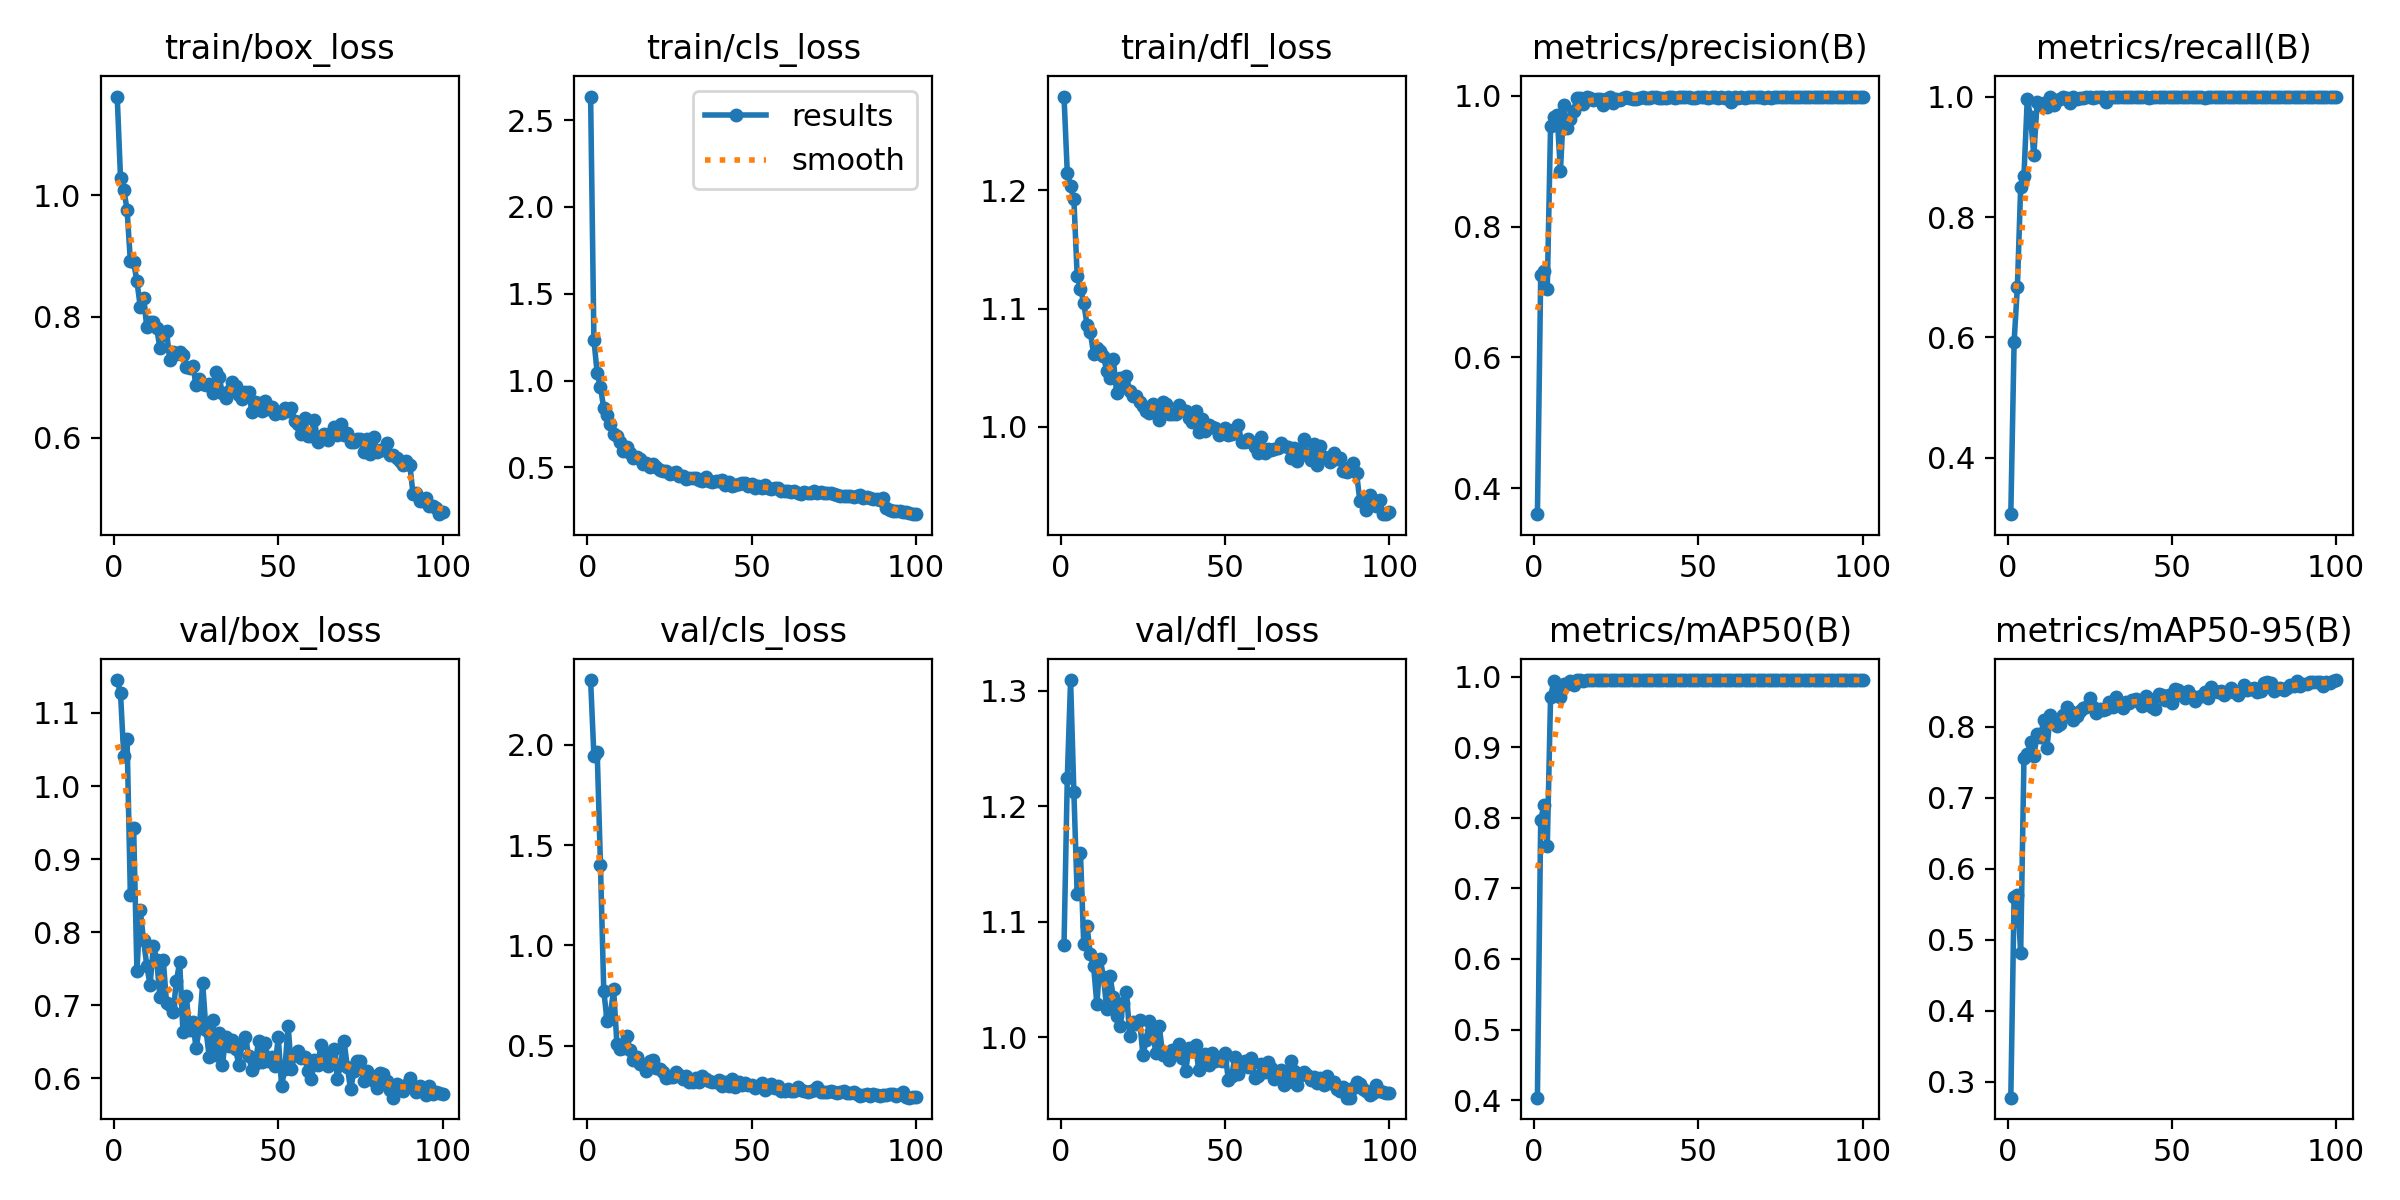


🎯 Matrice de Confusion :


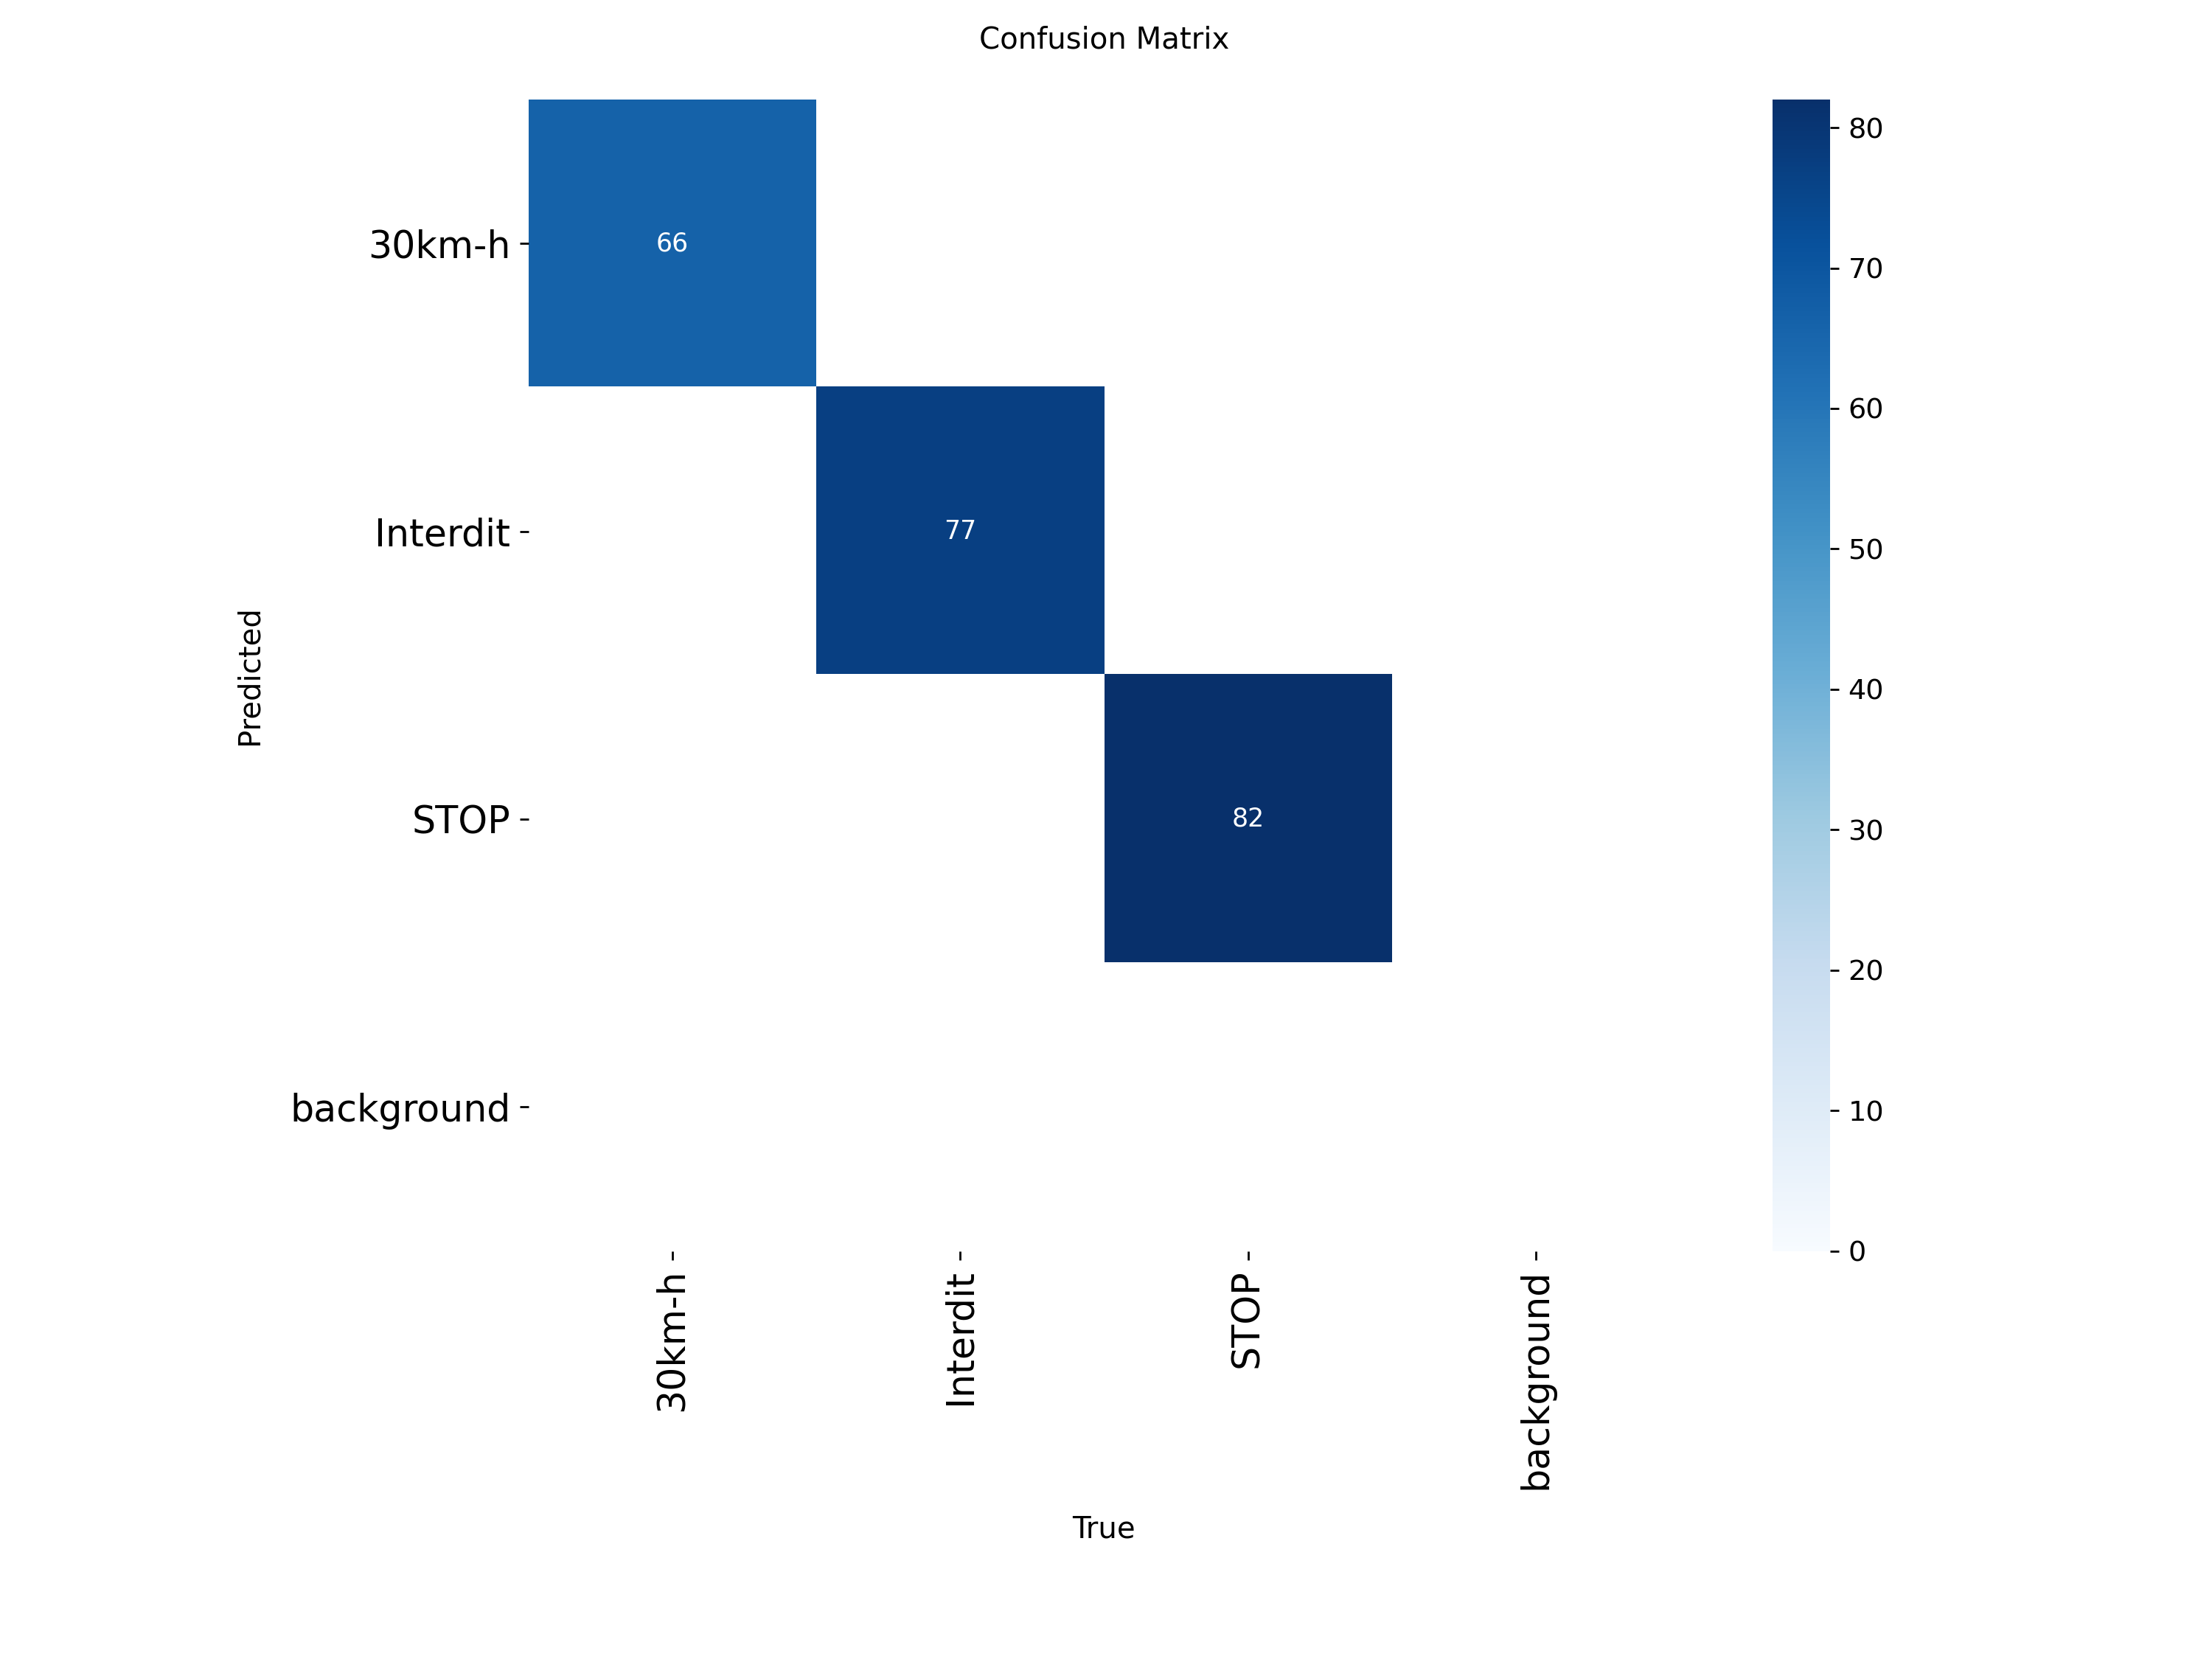


🖼️ Exemples de détection sur tes images de validation :


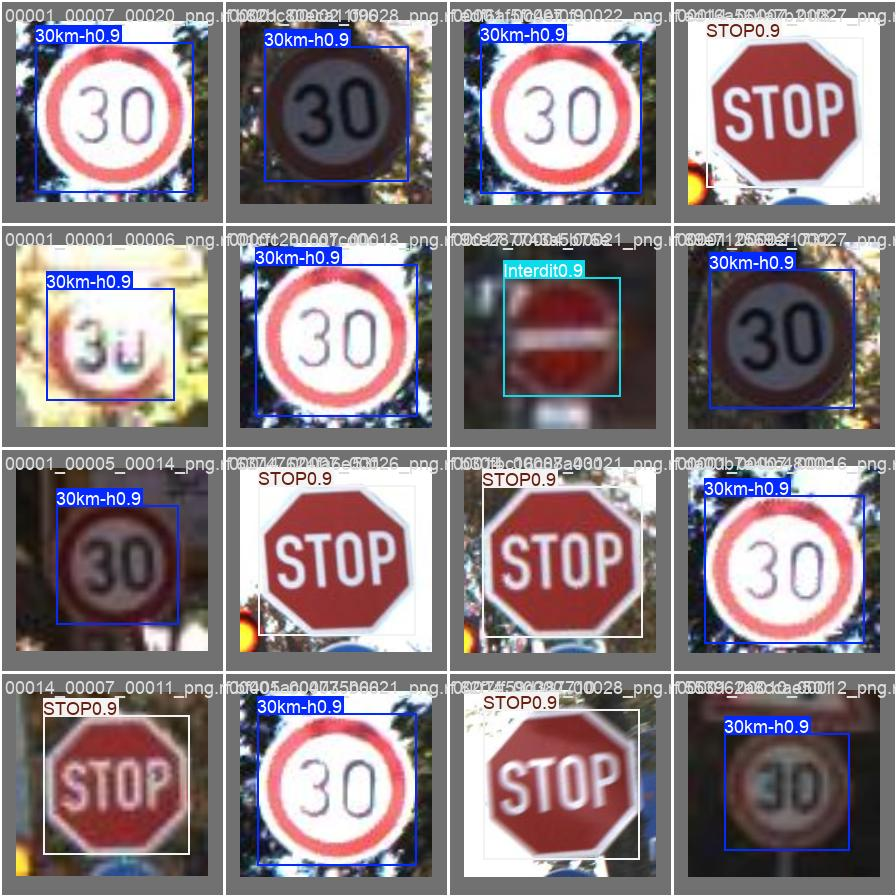

In [ ]:
from IPython.display import Image, display

print("📊 Courbes d'apprentissage (Loss & mAP) :")
# Affiche l'évolution de la précision. Cherche la courbe "mAP50", elle doit monter !
display(Image(filename=f'{results.save_dir}/results.png', width=1000))

print("\n🎯 Matrice de Confusion :")
# Vérifie si le modèle confond un Stop avec un Sens Interdit ou le fond (background)
display(Image(filename=f'{results.save_dir}/confusion_matrix.png', width=800))

print("\n🖼️ Exemples de détection sur tes images de validation :")
display(Image(filename=f'{results.save_dir}/val_batch0_pred.jpg', width=1000))

🚀 Lancement de l'examen final sur les images de Test...

image 1/114 /content/Panneau-2/test/images/00001_00000_00000_png.rf.06cd64458cf7667e08634494b16a7cb3.jpg: 192x192 1 30km-h, 6.5ms
image 2/114 /content/Panneau-2/test/images/00001_00001_00002_png.rf.9a075fbc48ca4ec9d05b333a46dc07b0.jpg: 192x192 1 30km-h, 6.7ms
image 3/114 /content/Panneau-2/test/images/00001_00001_00022_png.rf.e5e7f42f5f209b5522de566eecd05102.jpg: 192x192 1 30km-h, 6.3ms
image 4/114 /content/Panneau-2/test/images/00001_00001_00025_png.rf.dac90a832f02fa6c5374b0b72ded9d9f.jpg: 192x192 1 30km-h, 6.3ms
image 5/114 /content/Panneau-2/test/images/00001_00001_00027_png.rf.29cec6e767d7f8a30456bbca02b0eac3.jpg: 192x192 1 30km-h, 10.3ms
image 6/114 /content/Panneau-2/test/images/00001_00002_00023_png.rf.22542cd2af3a651e9d7da60fce4c3300.jpg: 192x192 1 30km-h, 8.4ms
image 7/114 /content/Panneau-2/test/images/00001_00003_00013_png.rf.e395c5119df5b8b3ad4cd3f9ed475109.jpg: 192x192 1 30km-h, 7.9ms
image 8/114 /content/Panneau-2/t

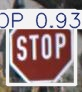

--------------------------------------------------


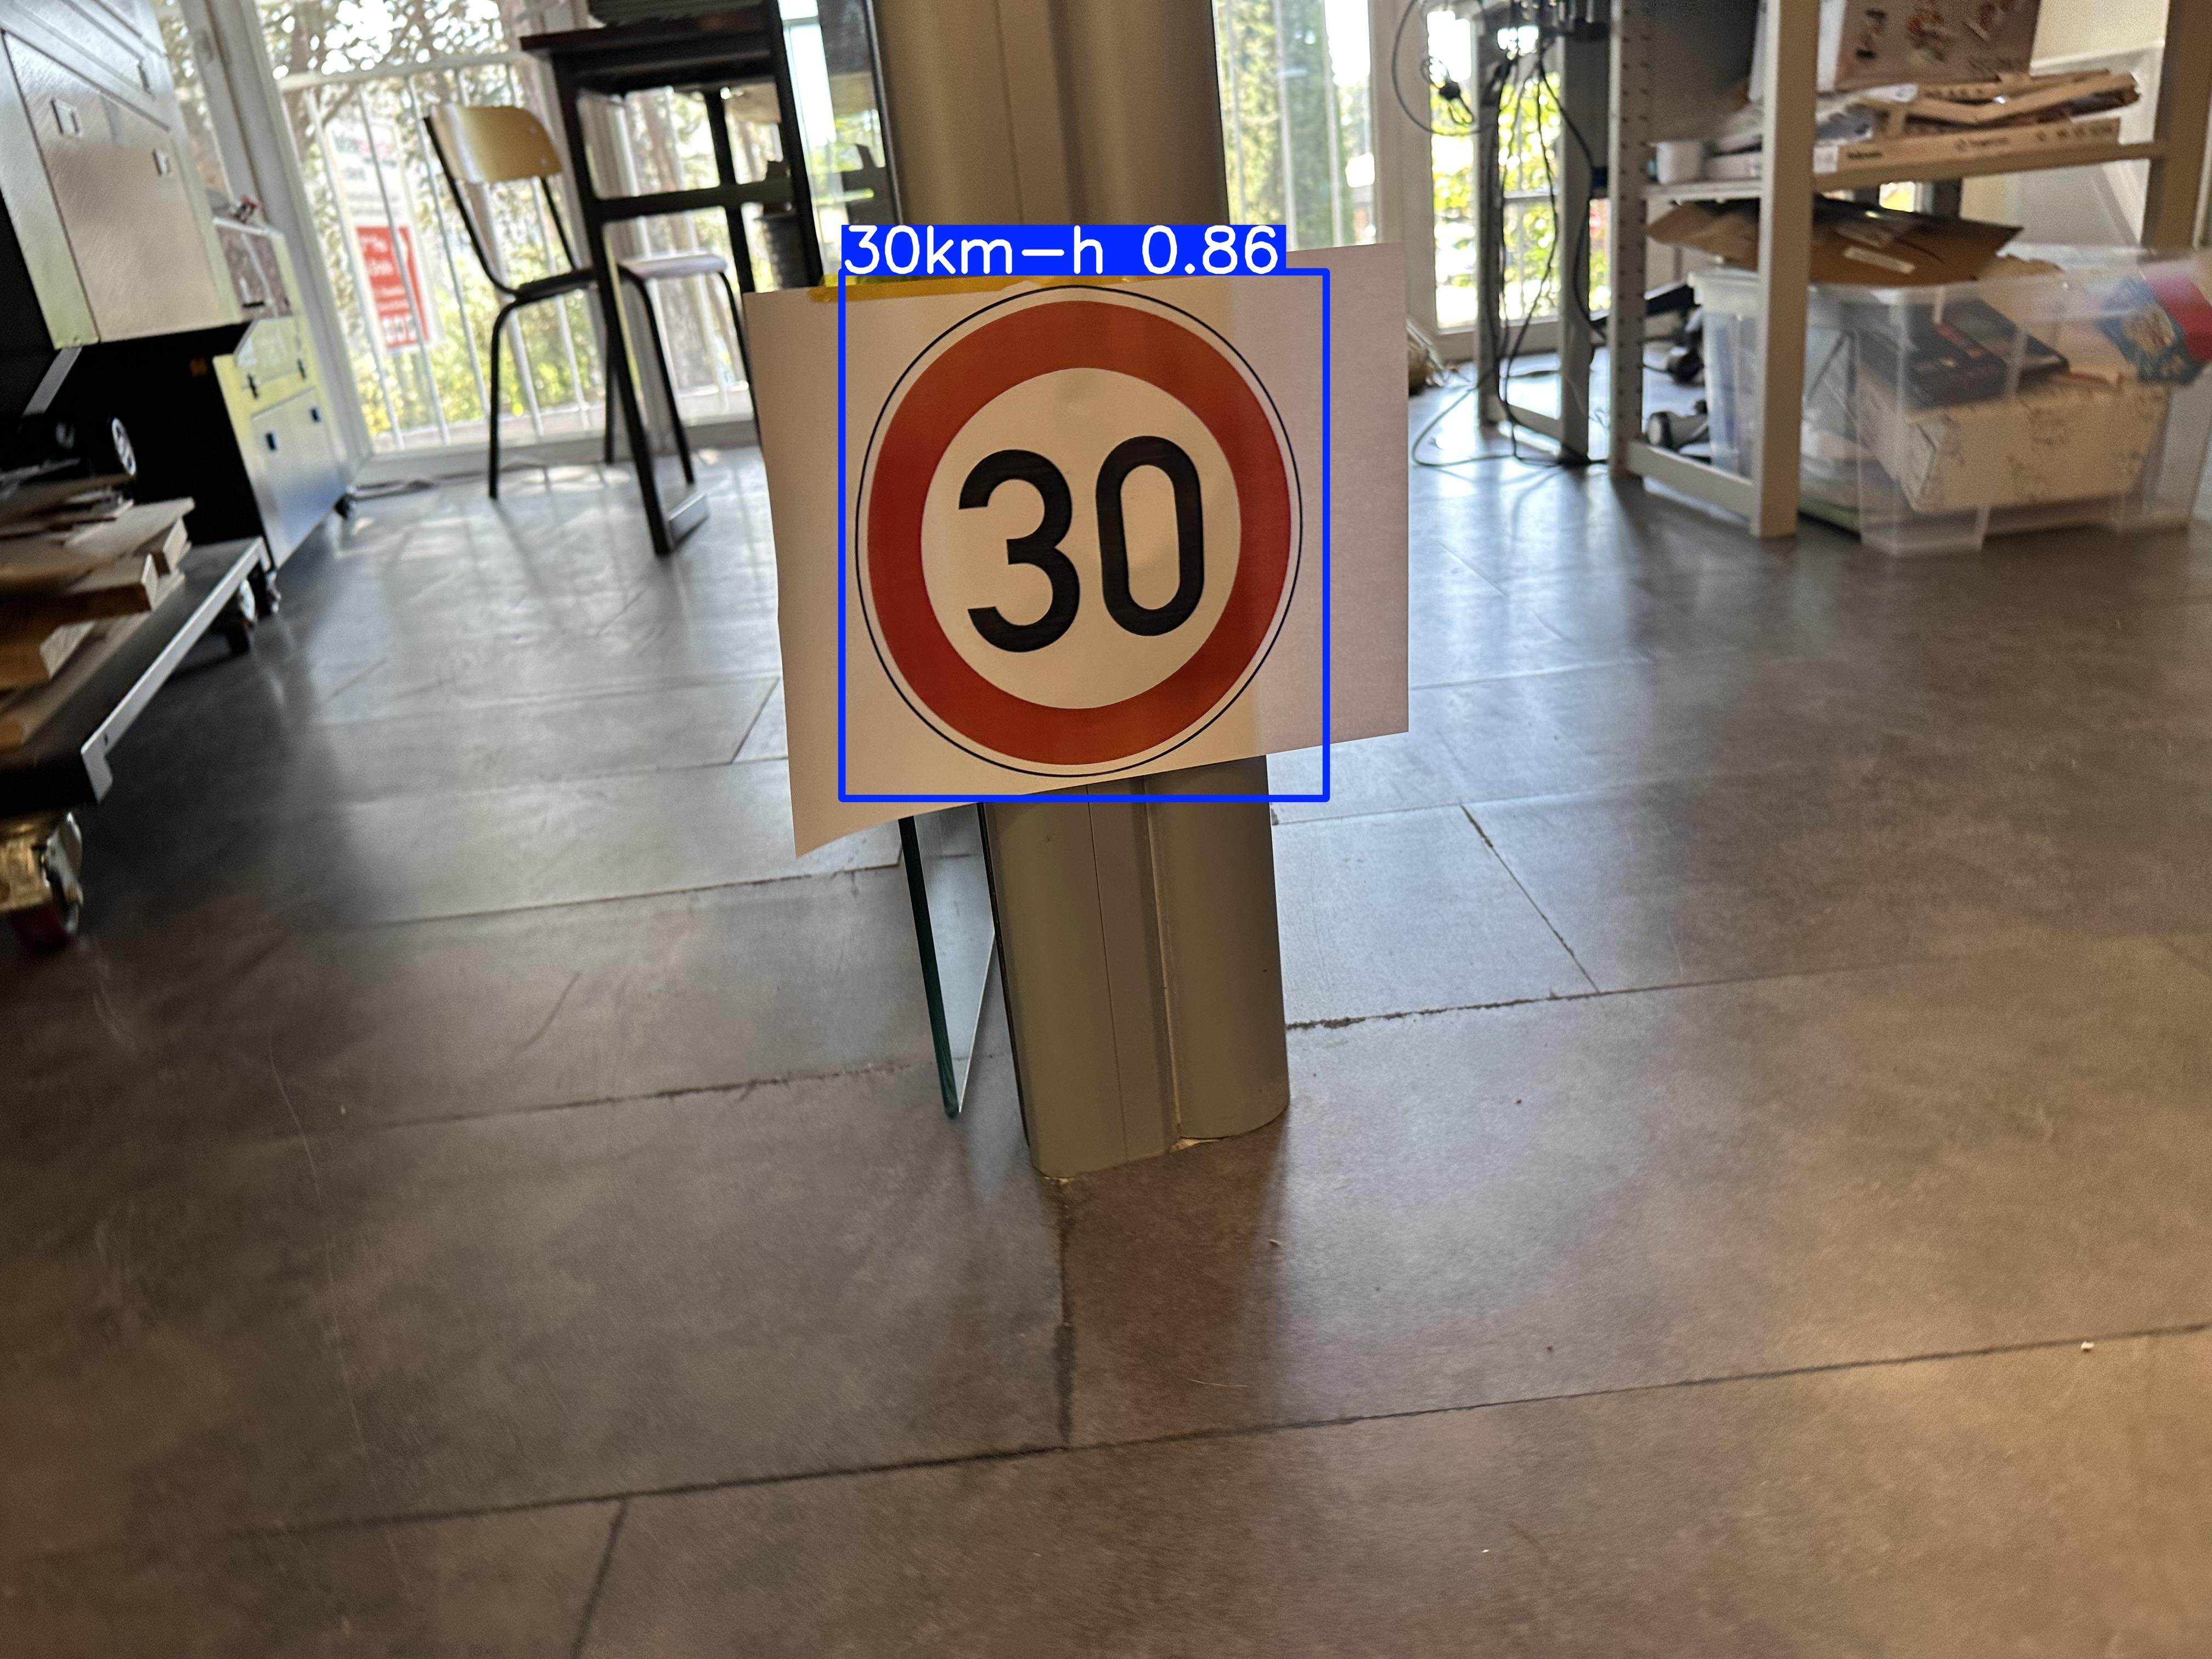

--------------------------------------------------


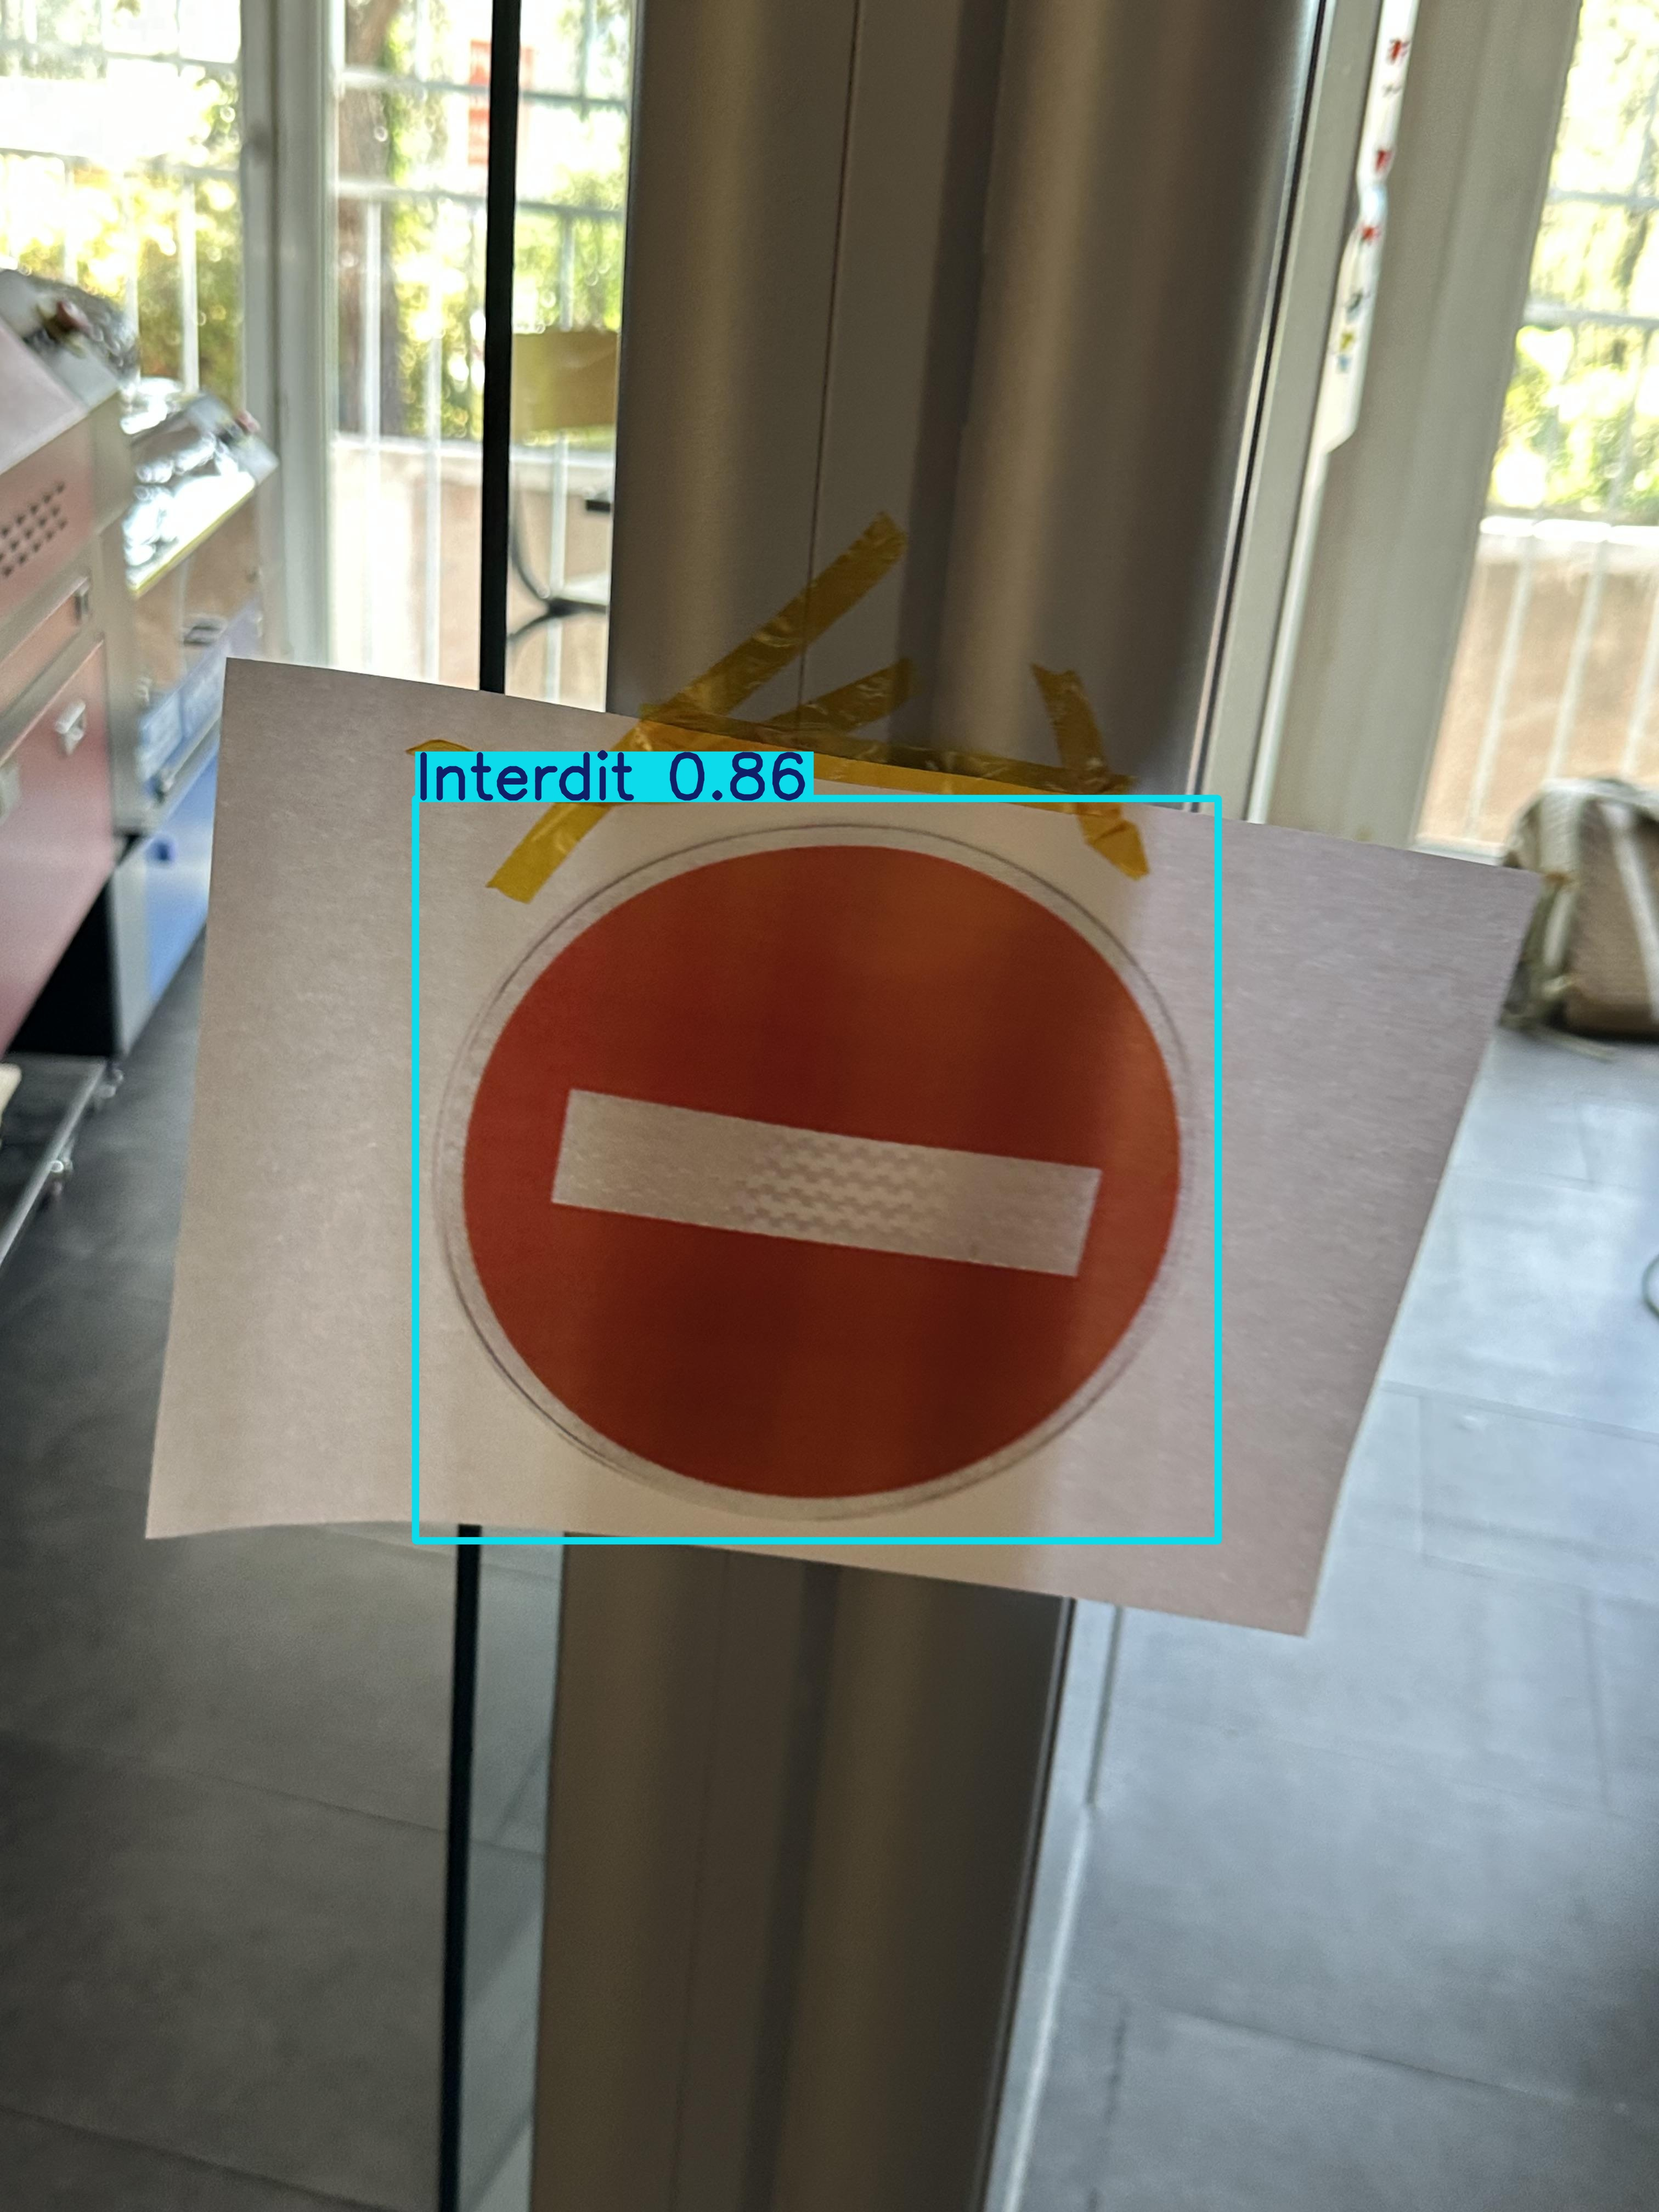

--------------------------------------------------


In [ ]:
import glob
import os
from IPython.display import Image, display

print("🚀 Lancement de l'examen final sur les images de Test...")

# 1. On demande au modèle de prédire sur le dossier "test" (images jamais vues)
# save=True : il va sauvegarder les images avec les rectangles dessinés dessus
# conf=0.25 : il ne garde que les détections où il est sûr à plus de 25%
predictions = model.predict(
    source=f"{dataset.location}/test/images",
    save=True,
    conf=0.25
)

# 2. On récupère le dossier où il a sauvegardé ses dessins
dossier_sauvegarde = predictions[0].save_dir

# 3. On cherche les images et on affiche les 3 premières dans le Notebook
images_test = glob.glob(os.path.join(dossier_sauvegarde, '*.jpg'))[:3]

print("\n🖼️ Voici ce que l'IA a vu :")
for img in images_test:
    display(Image(filename=img, width=600))
    print("-" * 50)

In [ ]:
# --- ÉTAPE 6 COMPLÈTE : EXPORT ET MODÈLE HYBRIDE ---
import os
import glob
import tensorflow as tf
from google.colab import files

print("⚙️ 1. Lancement de l'exportation de base YOLO...")
path_export = model.export(
    format='tflite',
    int8=True,
    data=f"{dataset.location}/data.yaml",
    imgsz=192
)

print(f"✅ Exportation terminée : {path_export}")

print("\n⚙️ 2. Lancement de la conversion Hybride (Entrée INT8 / Sortie FLOAT32)...")

# LA CORRECTION EST ICI : On récupère juste le dossier parent du fichier généré !
saved_model_dir = os.path.dirname(path_export)
print(f"📂 Dossier SavedModel trouvé : {saved_model_dir}")

# Configuration du convertisseur TensorFlow
converter = tf.lite.TFLiteConverter.from_saved_model(saved_model_dir)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

# Le Modèle Hybride : Entrée en INT8 (NPU) et Sortie en FLOAT (OpenMV)
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.float32

# Fonction de calibration
def representative_dataset():
    for img_path in glob.glob(f"{dataset.location}/test/images/*.jpg")[:100]:
        img = tf.keras.preprocessing.image.load_img(img_path, target_size=(192, 192))
        img_array = tf.keras.preprocessing.image.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0)
        img_array = img_array / 255.0
        yield [tf.cast(img_array, tf.float32)]

converter.representative_dataset = representative_dataset
tflite_quant_model = converter.convert()

# Sauvegarde et téléchargement
nom_final = 'network_hybride.tflite'
with open(nom_final, 'wb') as f:
    f.write(tflite_quant_model)

print(f"\n🚀 Téléchargement automatique de {nom_final}...")
files.download(nom_final)

⚙️ 1. Lancement de l'exportation de base YOLO...
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/content/runs/detect/N6Cam_Project/Yolo_Panneaux_ReLU/weights/best.pt' with input shape (1, 3, 192, 192) BCHW and output shape(s) (1, 7, 756) (5.9 MB)
TensorFlow SavedModel: collecting INT8 calibration images from 'data=/content/Panneau-2/data.yaml'
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 137.3±227.4 MB/s, size: 255.3 KB)
val: Scanning /content/Panneau-2/valid/labels.cache... 225 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 225/225 52.4Mit/s 0.0s
WARNING ⚠️ TensorFlow SavedModel: >300 images recommended for INT8 calibration, found 225 images.

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 1.5s, saved as '/content/runs/detect/N6Cam_Project/Yolo_Panneaux_ReLU/weights/best.onnx' (11.5 MB)

TensorFlow SavedModel: starting export with tensorflow 2.20.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>